In [1]:
import pandas as pd

data = pd.read_csv('../data/herg_dataset.csv')
data.head()

,SourceID,SMILES,PIC50,USED_AS
0,CHEMBL428777,C[C@@H](Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3...,4.85,Dev-set
1,CHEMBL258313,C[C@@H](Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3...,4.92,Dev-set
2,CHEMBL403774,C[C@@H](Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3...,5.00,Dev-set
3,CHEMBL402011,C[C@@H](Oc1cccc2ncnc(Nc3ccc4c(cnn4Cc5ccccn5)c3...,4.60,Dev-set
4,CHEMBL379816,C[C@@H](O[C@H]1CCNC(=O)C[C@@H]1c2ccc(F)cc2)c3c...,5.00,Dev-set


In [2]:
data = data[['SMILES', 'PIC50']]
data.rename(columns={'PIC50': 'pic50', 'SMILES': 'smiles'}, inplace=True)
data.head()

,smiles,pic50
0,C[C@@H](Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3...,4.85
1,C[C@@H](Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3...,4.92
2,C[C@@H](Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3...,5.00
3,C[C@@H](Oc1cccc2ncnc(Nc3ccc4c(cnn4Cc5ccccn5)c3...,4.60
4,C[C@@H](O[C@H]1CCNC(=O)C[C@@H]1c2ccc(F)cc2)c3c...,5.00


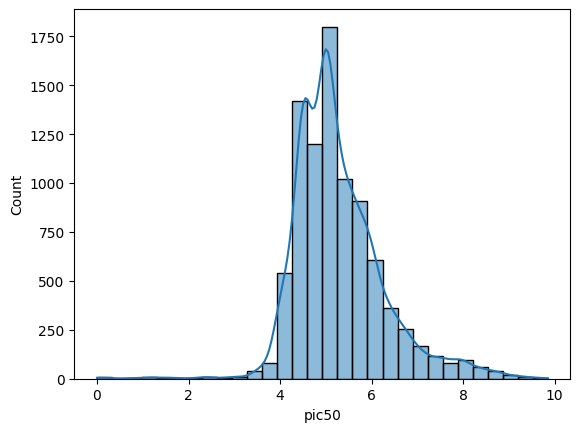

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data, x='pic50', bins=30, kde=True)
plt.show()

In [4]:
print(len(data))
data = data[data['pic50'] > 2].reset_index(drop=True)
len(data)

8879


8852

In [5]:
len(data)

8852

In [6]:
from rdkit import Chem

mols = [Chem.MolFromSmiles(smi) for smi in data['smiles']]
valid_mols_ids = [i for i, m in enumerate(mols) if m is not None]
data = data.iloc[valid_mols_ids].reset_index(drop=True)
len(data)

8852

In [7]:
mols = [m for m in mols if m is not None]
len(mols)

8852

In [8]:
from src.core.utils import select_diverse_subset_butina

num_samples = 200
diverse_indices = select_diverse_subset_butina(mols, num_samples, similarity_cutoff=0.6)
data = data.iloc[diverse_indices].reset_index(drop=True)
data.head()

[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerator
[22:06:01] DEPRECATION WARNING: please use MorganGenerat

,smiles,pic50
0,CO[C@]1(CC23CCC(CC2)(CO3)NCc4ccc5OCC(=O)Nc5n4)...,4.61
1,Cc1oc2cc3CCN(CCCSc4nnc(c5ocnc5C)n4C)CCc3cc2n1,4.50
2,CN(C)c1ncc(cn1)[C@@H]2CC[C@H](CC2)N3CC(C3)NC(=...,5.01
3,C(COc1ccc(cc1)N2CCCCC2)CN3CCCCC3,6.10
4,CC1(C)Oc2ccc(cc2C3(COC(=N3)N)C14COC4)c5cccnc5F,5.00


In [9]:
len(data)

200

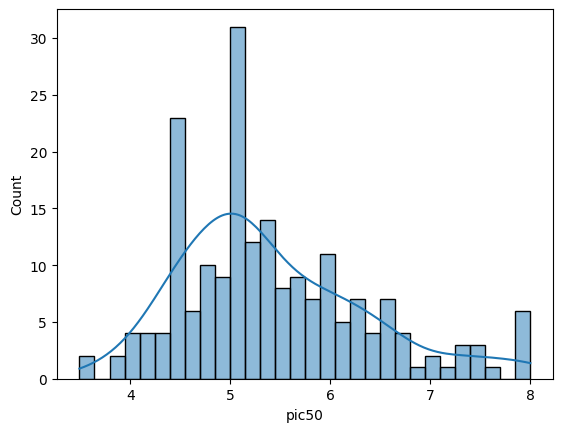

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data, x='pic50', bins=30, kde=True)
plt.show()

In [11]:
from src.core.fingerprints import Fingerprints
df = data

names = ['ecfp']
params = {
    'ecfp': {'radius': 2, 'size': 1024, 'count': True},
}
fingerprints, f_names = Fingerprints().apply(
    smiles=df['smiles'].tolist(),
    names=names,
    **params
)
df_fingerprints = pd.DataFrame(fingerprints, columns=f_names)
threshold = 0.85
df_fingerprints = df_fingerprints[[col for col in df_fingerprints.columns if df_fingerprints[col].value_counts(normalize=True).iloc[0] <= threshold]]
df_fingerprints = df_fingerprints.loc[:, df_fingerprints.nunique() > 1]
df_fingerprints['pic50'] = df['pic50'].values
df_fingerprints['smiles'] = df['smiles'].values

df_fingerprints

,ecfp_feature_1,ecfp_feature_4,ecfp_feature_15,ecfp_feature_33,ecfp_feature_36,ecfp_feature_64,ecfp_feature_73,ecfp_feature_80,ecfp_feature_90,ecfp_feature_114,...,ecfp_feature_881,ecfp_feature_893,ecfp_feature_896,ecfp_feature_904,ecfp_feature_926,ecfp_feature_935,ecfp_feature_985,ecfp_feature_1019,pic50,smiles
0,0,0,1,1,4,0,1,2,1,0,...,1,0,0,1,7,1,0,0,4.61,CO[C@]1(CC23CCC(CC2)(CO3)NCc4ccc5OCC(=O)Nc5n4)...
1,0,0,1,3,0,0,1,3,0,0,...,0,0,0,0,4,2,0,0,4.50,Cc1oc2cc3CCN(CCCSc4nnc(c5ocnc5C)n4C)CCc3cc2n1
2,0,0,1,2,0,1,0,1,0,1,...,1,2,0,3,6,1,0,3,5.01,CN(C)c1ncc(cn1)[C@@H]2CC[C@H](CC2)N3CC(C3)NC(=...
3,0,6,0,0,0,0,0,3,0,0,...,0,0,0,0,10,2,0,0,6.10,C(COc1ccc(cc1)N2CCCCC2)CN3CCCCC3
4,0,0,0,2,3,1,0,0,0,0,...,2,0,1,1,3,0,0,0,5.00,CC1(C)Oc2ccc(cc2C3(COC(=N3)N)C14COC4)c5cccnc5F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,0,3,1,0,0,1,0,1,...,3,0,1,3,1,0,0,0,4.80,CC(C)(C)COc1ccc2Oc3ccc(cc3[C@@]4(COC(=N4)N)c2c...
196,0,1,0,0,1,1,0,1,1,1,...,0,1,1,0,7,1,0,0,5.80,Nc1ccc(cc1NC(=O)c2ccc(CN3CCC4(CCCN4)CC3)cc2)c5...
197,0,0,0,3,1,0,0,3,0,1,...,0,1,0,1,4,1,0,0,5.65,CC(C)(C)CCN1CCC(F)(CNC(=O)c2cc(Cl)cc(Cl)c2)CC1
198,0,0,0,1,0,2,0,2,0,0,...,0,1,2,1,4,2,0,0,4.50,CCN1CCN(Cc2cnc(c(F)c2)c3ccc(cc3)C(=O)Nc4ccccc4...


In [13]:
df_fingerprints.to_csv('../data/herg_data/data_herg_ecfp.csv', index=False)

In [16]:
1/10 * (df_fingerprints['pic50'].max() - df_fingerprints['pic50'].min())

np.float64(0.451)